# From two particles in to two out: cross sections, derived and checked

*For a reader who has been through the [Particle Decays Tutorial](Particle_Decays_Tutorial.ipynb)
— who knows what a spin sum, a Dirac trace and a width are — but has never carried a
**cross section** all the way to a number.*

A decay is one particle becoming two; what we measure is a rate per particle, $\Gamma$. A
collider does the opposite: two particles **meet** and become two others, and what we measure
is a rate per unit flux — a **cross section** $\sigma$, in picobarns. Almost every number a
collider has ever published is one. This notebook builds them from a Lagrangian.

The pedagogy is **compute step by step, then develop judgment**. Nothing below is typed in
from the answer. The kinematics is *derived* from momentum conservation; every closed form is
*asserted*, not admired; the first squared amplitude is *evaluated twice* — once by the
covariant engine, once with explicit $4\times4$ Dirac matrices; and only once an amplitude has
been built by hand do we reach for `ScatteringCalculator`, which builds every diagram itself —
and check that it agrees, with the textbooks and with MadGraph.

Each section runs four moves — **set up** (look at the raw object), **collect** (let the
structure emerge), **recognise** (name what appeared and why it had to), **check** (from
physics or from an independent route, as an `assert`). Before most cells there is a prediction
to make. Make it. The value of this notebook is in the gap between what you expected and what
printed.

**Roadmap**

1. Two invariants describe every 2→2 event
2. A cross section is flux × $|\mathcal M|^2$ × phase space
3. One photon gives $1+\cos^2\theta$ — computed two ways
4. Chiral currents leave an $\varepsilon\cdot\varepsilon$ term no decay ever had
5. The Z alone tilts forward: $A_{FB}=\tfrac34A_eA_\mu$
6. Two diagrams interfere — and the observable picks which couplings
7. Exchanged pairings: one trace, one minus sign
8. Capstone: Møller scattering by hand
9. Recap
10. References

This is Tiers 1–3 of `docs/manual/scattering_roadmap.md` (chapter 17).

In [ ]:
import math

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex="mathjax")   # text/latex only -- no PNG mimetype

from sympy.combinatorics import Permutation

from feynlag import (
    Lagrangian, Model, WeylFermion, electroweak_scaffold,
    fermion_gauge_current, to_physical_basis,
)
from feynlag.dirac import _dirac_rep
from feynlag.pheno import (
    Amplitude, BosonPropagator, ChainVertex, Diagram, DiracParticle,
    ExternalState, Leg, ScatteringCalculator, SpinorChain, TwoToTwoKinematics,
    cross_section, differential_cross_section, ffv_s_channel_squared,
    forward_backward_asymmetry,
)
from feynlag.pheno.diagrams import _chain_indices
from feynlag.pheno.epsilon import (
    epsilon_product_sign, gamma5_trace_coefficient, gram_determinant,
    levi_civita_array,
)


def ok(msg):
    print("✓", msg)


def trace(msg, obj=None):
    # One line of commentary, optionally followed by a sympy object -- the
    # same helper as the Decays tutorial: the cells that assert stay quiet,
    # the "peek" cells do the talking.
    print(msg)
    if obj is not None:
        display(obj)


def close(x, target, rel):
    # |x - target| <= rel * |target|: the only way a float meets a benchmark.
    return abs(x - target) <= rel * abs(target)


GEV2_TO_PB = 0.3893794e9     # (hbar c)^2: 1 GeV^-2 = 0.3894 mb = 3.894e8 pb [PDG]

---
## 1. Two invariants describe every 2→2 event

Label the process $1(k_1)+2(k_2)\to3(k_3)+4(k_4)$. Four four-momenta is sixteen numbers, but
each particle is on shell ($k_i^2=m_i^2$, −4), momentum is conserved ($k_1+k_2=k_3+k_4$, −4),
and a Lorentz transformation can rotate and boost the whole event away (−6). That leaves
**two**. The traditional pair, built to be Lorentz invariant, is

$$s=(k_1+k_2)^2,\qquad t=(k_1-k_3)^2,\qquad u=(k_1-k_4)^2 .$$

`TwoToTwoKinematics` takes $(s,t)$ as its two symbols and makes $u$ a **derived property**,
never a third free symbol — so momentum conservation holds by construction, not by a check the
caller has to remember. ($s,t$ rather than $s,\cos\theta$, because the on-shell dot-product
table is then *linear* — $\cos\theta$ would drag a square-root Källén function into every
entry, and from there into every Dirac trace.)

> **Before running the next cell.** Three invariants, two degrees of freedom: so $s+t+u$ must be
> a constant. Expand the three squares and say which constant.

In [ ]:
# ---- MOVE 1 + 4: the Mandelstam identity and momentum conservation. --------
m1, m2, m3, m4 = sp.symbols("m1 m2 m3 m4", positive=True)
kin = TwoToTwoKinematics(m1, m2, m3, m4)
trace("u, as the kinematics object returns it:", kin.u)

assert sp.expand(kin.s + kin.t + kin.u - (m1**2 + m2**2 + m3**2 + m4**2)) == 0
ok("s + t + u = m1^2 + m2^2 + m3^2 + m4^2 -- u is not independent")

# k4 has its own momentum head, so conservation is a property of the dot table
lhs = kin.dot(kin.k4, kin.k1)
rhs = kin.dot(kin.k1, kin.k1) + kin.dot(kin.k2, kin.k1) - kin.dot(kin.k3, kin.k1)
assert sp.expand(lhs - rhs) == 0
ok("k4.k1 = (k1 + k2 - k3).k1 -- the dot table conserves momentum")

u, as the kinematics object returns it:


  2     2     2     2        
m₁  + m₂  + m₃  + m₄  - s - t

✓ s + t + u = m1^2 + m2^2 + m3^2 + m4^2 -- u is not independent
✓ k4.k1 = (k1 + k2 - k3).k1 -- the dot table conserves momentum


**Recognise.** In the centre-of-mass frame $s$ is the total energy squared, and $t$ is fixed by
the scattering angle: $t = t_0 + \Delta\cos\theta$, linear in $\cos\theta$. So the physical
region at fixed $s$ is a $t$-interval whose ends are forward ($\cos\theta=1$) and backward
($\cos\theta=-1$) scattering. The flux of the incoming beams is the last kinematic ingredient;
for massless beams it must reduce to the familiar $1/(2s)$.

In [ ]:
# ---- MOVE 2 + 4: the t range is the cos(theta) range; the massless flux. ----
t_lo, t_hi = kin.t_bounds()
assert sp.simplify(t_lo - kin.t_of_cos(-1)) == 0
assert sp.simplify(t_hi - kin.t_of_cos(1)) == 0
ok("t_bounds are exactly cos(theta) = -1 (backward) and +1 (forward)")

kin0 = TwoToTwoKinematics(0, 0, 0, 0)
assert sp.simplify(kin0.flux_factor() - 1 / (2 * kin0.s)) == 0
assert sp.simplify(kin0.t_of_cos(sp.Symbol("c")) + kin0.s * (1 - sp.Symbol("c")) / 2) == 0
ok("massless: flux = 1/(2s) and t = -s(1 - cos theta)/2")

✓ t_bounds are exactly cos(theta) = -1 (backward) and +1 (forward)
✓ massless: flux = 1/(2s) and t = -s(1 - cos theta)/2


---
## 2. A cross section is flux × $|\mathcal M|^2$ × phase space

Fermi's golden rule for scattering reads

$$d\sigma = \frac{1}{\text{flux}}\;\overline{|\mathcal M|^2}\;d\Phi_2,\qquad
\overline{|\mathcal M|^2}=\frac{1}{(2s_1+1)(2s_2+1)}\sum_\text{spins}|\mathcal M|^2 .$$

For massless particles in the CM frame the two-body phase space is $d\Phi_2 = d\cos\theta/(16\pi)$
(times $d\phi/2\pi$), and the flux is $2s$. So

$$\frac{d\sigma}{d\cos\theta}=\frac{1}{4}\,\frac{\sum|\mathcal M|^2}{32\pi s}\quad
\text{for two unpolarised spin-}\tfrac12\text{ beams.}$$

The **average** over the incoming spins (the ¼) is the one factor that belongs to the
*initial state*, not to the amplitude. feynlag keeps it as declared data — an `ExternalState`
with a spin — and applies it once, never inside $|\mathcal M|^2$.

> **Before running the next cell.** Suppose $\sum|\mathcal M|^2 = X$ were a constant. Integrate
> over $\cos\theta\in[-1,1]$: what is $\sigma$, in terms of the *averaged* $\overline{|\mathcal M|^2}=X/4$?

In [ ]:
# ---- MOVE 1 + 4: the averaging, the conversion factor, a constant |M|^2. ----
X = sp.Symbol("X", positive=True)
electron = ExternalState("e", 0, sp.Rational(1, 2))
c = sp.Symbol("c", real=True)

dsdcos = differential_cross_section(X, kin0, (electron, electron), variable="cos")
assert sp.simplify(dsdcos - X / 4 / (32 * sp.pi * kin0.s)) == 0
ok("dsigma/dcos = (1/4) Sigma|M|^2 / (32 pi s): the 1/4 is the spin average, applied once")

sigma_const = cross_section(X, kin0, (electron, electron))
assert sp.simplify(sigma_const - (X / 4) / (16 * sp.pi * kin0.s)) == 0
ok("constant |M|^2:  sigma = <|M|^2> / (16 pi s)")

✓ dsigma/dcos = (1/4) Sigma|M|^2 / (32 pi s): the 1/4 is the spin average, applied once
✓ constant |M|^2:  sigma = <|M|^2> / (16 pi s)


---
## 3. One photon gives $1+\cos^2\theta$ — computed two ways

The simplest real process: $e^+e^-\to\mu^+\mu^-$ through one virtual photon. Unlike the decay
engine, which writes down an already-squared closed form, `feynlag.pheno.diagrams` builds the
**amplitude**: two open fermion lines (`SpinorChain`), each with a vertex (`ChainVertex`),
joined by a propagator (`BosonPropagator`) inside a `Diagram`. That is what will let us attach
a second diagram later. `ffv_s_channel_squared` assembles the one-vector s-channel case.

The textbook result, with the muon mass kept, is [PS95, §5.1]

$$\sum|\mathcal M|^2 = \frac{8e^4}{s^2}\left[(t-m^2)^2+(u-m^2)^2+2m^2s\right],\qquad
\sigma=\frac{4\pi\alpha^2}{3s}\,\frac{\beta(3-\beta^2)}{2},\quad \beta=\sqrt{1-4m^2/s}.$$

> **Before running the next cell.** Set $m=0$. In the CM frame $t=-\tfrac s2(1-\cos\theta)$ and
> $u=-\tfrac s2(1+\cos\theta)$. What angular shape does $t^2+u^2$ give — and is it symmetric
> between forward and backward?

In [ ]:
# ---- MOVE 1 + 2: the covariant |M|^2 and sigma, against the closed forms. ---
m, e = sp.symbols("m e", positive=True)
kin_qed = TwoToTwoKinematics(0, 0, m, m)
m2_qed = ffv_s_channel_squared(e, e, e, e, kin_qed, mediator_mass=0)

s, t, u = kin_qed.s, kin_qed.t, kin_qed.u
textbook = 8 * e**4 / s**2 * ((t - m**2)**2 + (u - m**2)**2 + 2 * m**2 * s)
assert sp.simplify(sp.expand(m2_qed - textbook)) == 0
ok("Sigma|M|^2 = 8e^4/s^2 [(t-m^2)^2 + (u-m^2)^2 + 2m^2 s]   [PS95 5.1]")

sigma_qed = sp.simplify(cross_section(m2_qed, kin_qed, (electron, electron)))
beta = sp.sqrt(1 - 4 * m**2 / s)
alpha = e**2 / (4 * sp.pi)
assert sp.simplify(sigma_qed - 4 * sp.pi * alpha**2 / (3 * s) * beta * (3 - beta**2) / 2) == 0
ok("sigma = (4 pi alpha^2 / 3s) beta (3 - beta^2)/2   [PS95 5.1]")

shape = sp.simplify(m2_qed.subs(m, 0).subs(kin_qed.t, kin0.t_of_cos(c)) / e**4)
assert sp.simplify(shape - 4 * (1 + c**2)) == 0
ok("massless: Sigma|M|^2 = 4 e^4 (1 + cos^2 theta) -- symmetric forward/backward")

✓ Sigma|M|^2 = 8e^4/s^2 [(t-m^2)^2 + (u-m^2)^2 + 2m^2 s]   [PS95 5.1]
✓ sigma = (4 pi alpha^2 / 3s) beta (3 - beta^2)/2   [PS95 5.1]
✓ massless: Sigma|M|^2 = 4 e^4 (1 + cos^2 theta) -- symmetric forward/backward


Agreement with a textbook formula is not independent of *conventions* — both could carry the
same slip. So evaluate the same quantity a second way that shares no code with the engine:
pick explicit CM-frame four-vectors, write $\not k\pm m$ and $\gamma^\mu$ as literal $4\times4$
matrices, take the two traces numerically-exactly, and contract them by hand.

In [ ]:
# ---- MOVE 4: the same |M|^2 from literal 4x4 Dirac matrices. -----------------
rep = _dirac_rep()
G = [rep[("g", mu)] for mu in range(4)]
MET = sp.diag(1, -1, -1, -1)


def slash(p):
    return sum((MET[a, a] * p[a] * G[a] for a in range(4)), sp.zeros(4))


def qed_matrix_m2(s_val, cos_val, mass, e_val):
    E, p_in = sp.sqrt(s_val) / 2, sp.sqrt(s_val) / 2
    p_out, sin = sp.sqrt(s_val / 4 - mass**2), sp.sqrt(1 - cos_val**2)
    k1, k2 = [E, 0, 0, p_in], [E, 0, 0, -p_in]
    k3 = [E, p_out * sin, 0, p_out * cos_val]
    k4 = [E, -p_out * sin, 0, -p_out * cos_val]
    # incoming line: Tr[k2 g^mu k1 g^nu];  outgoing: Tr[(k3+m) g_mu (k4-m) g_nu]
    T_in = [[(slash(k2) * G[a] * slash(k1) * G[b]).trace() for b in range(4)] for a in range(4)]
    T_out = [[((slash(k3) + mass * sp.eye(4)) * G[a] * (slash(k4) - mass * sp.eye(4)) * G[b]).trace()
              for b in range(4)] for a in range(4)]
    total = sum(T_in[a][b] * MET[a, a] * MET[b, b] * T_out[a][b] for a in range(4) for b in range(4))
    return sp.nsimplify(e_val**4 * total / s_val**2)


for s_val, cos_val, mass in ((sp.Integer(40), sp.Rational(1, 3), sp.Integer(1)),
                             (sp.Integer(100), sp.Rational(-3, 5), sp.Integer(2))):
    point = {m: mass, kin_qed.s: s_val, kin_qed.t: kin_qed.t_of_cos(cos_val).subs({m: mass, kin_qed.s: s_val})}
    covariant = sp.nsimplify(sp.simplify(m2_qed.subs(point).subs(e, 1)))
    assert sp.simplify(covariant - qed_matrix_m2(s_val, cos_val, mass, 1)) == 0
ok("covariant engine == explicit 4x4 traces, exactly, at two massive CM points")

✓ covariant engine == explicit 4x4 traces, exactly, at two massive CM points


**Recognise.** The photon couples identically to left- and right-handed fermions — a *vector*
coupling — and the result is the symmetric $1+\cos^2\theta$. At the benchmark point used
throughout this notebook — MadGraph's electroweak input scheme, $\alpha^{-1}=132.50698$, at
$\sqrt s=200$ GeV (`docs/benchmark.md`) — that is a definite number. Hold on to it: it is
**the photon alone**, over the full angle, and §6 will show it is not what a generator reports.

In [ ]:
# ---- MOVE 4: the photon-only cross section at the benchmark point. -----------
AEWM1 = 132.50698
e_mg = math.sqrt(4 * math.pi / AEWM1)
sigma_photon_pb = float(sigma_qed.subs({e: e_mg, m: 0, kin_qed.s: 200.0**2})) * GEV2_TO_PB
print(f"sigma(e+e- -> gamma* -> mu+mu-) = {sigma_photon_pb:.4f} pb   (sqrt(s) = 200 GeV)")
assert close(sigma_photon_pb, 2.3225, 2e-4)
ok("photon only, full angle: 2.322 pb")

sigma(e+e- -> gamma* -> mu+mu-) = 2.3223 pb   (sqrt(s) = 200 GeV)
✓ photon only, full angle: 2.322 pb


---
## 4. Chiral currents leave an $\varepsilon\cdot\varepsilon$ term no decay ever had

The weak interaction is **chiral**: the Z couples to left- and right-handed fermions with
different strengths, $\Gamma=\gamma^\mu(g_LP_L+g_RP_R)$, $P_{L,R}=(1\mp\gamma_5)/2$. Every trace
with a projector splits as

$$\mathrm{Tr}[X P_{L,R}] = \tfrac12\mathrm{Tr}[X] \mp \tfrac12\mathrm{Tr}[X\gamma_5],
\qquad \mathrm{Tr}[\gamma^a\gamma^b\gamma^c\gamma^d\gamma_5]=\kappa\,\varepsilon^{abcd}.$$

$\varepsilon$ is totally antisymmetric, so contracted with momenta it needs four *independent*
ones. A **1→2 decay** never has them — that is why the Decays tutorial could drop the
$\gamma_5$ term every time. SymPy's tensor engine has no $\gamma_5$ at all, so feynlag's
`pheno.epsilon` builds the two identities it needs itself — and, like every sign in this
library, *derives* their constants from the explicit Dirac matrices rather than quoting them:
$\kappa$ from $\mathrm{Tr}[\gamma^0\gamma^1\gamma^2\gamma^3\gamma_5]$, and the sign $s_{\det}$ of
$\varepsilon^{a\ldots}\varepsilon^{b\ldots}=s_{\det}\det[g^{a_ib_j}]$ from the $(+,-,-,-)$ metric.

> **Before running the next cell.** With $\varepsilon^{0123}=+1$, is $\kappa$ real or imaginary?
> (Hint: $\gamma_5 = i\gamma^0\gamma^1\gamma^2\gamma^3$, and $(\gamma^0\gamma^1\gamma^2\gamma^3)^2=-1$.)

In [ ]:
# ---- MOVE 1 + 4: kappa and s_det, the library's values against the matrices. --
kappa = gamma5_trace_coefficient()
LC = levi_civita_array()
g5 = rep["g5"]
for a, b, c_, d in ((0, 1, 2, 3), (1, 0, 2, 3), (3, 2, 1, 0), (0, 0, 1, 2)):
    assert sp.simplify((G[a] * G[b] * G[c_] * G[d] * g5).trace() - kappa * LC[a, b, c_, d]) == 0
assert kappa == -4 * sp.I
ok("Tr[g^a g^b g^c g^d g5] = -4i eps^abcd -- kappa is imaginary, and its sign is derived")

self_contraction = sum(LC[a, b, c_, d] * LC[a, b, c_, d] * MET[a, a] * MET[b, b] * MET[c_, c_] * MET[d, d]
                       for a in range(4) for b in range(4) for c_ in range(4) for d in range(4))
assert self_contraction == -24 and epsilon_product_sign() == -1
ok("eps^abcd eps_abcd = -24 = s_det * 4!  ->  s_det = -1 in the (+,-,-,-) metric")

✓ Tr[g^a g^b g^c g^d g5] = -4i eps^abcd -- kappa is imaginary, and its sign is derived
✓ eps^abcd eps_abcd = -24 = s_det * 4!  ->  s_det = -1 in the (+,-,-,-) metric


How many independent momenta does a 2→2 process actually have? Four external momenta with one
conservation law: **three**. The test for linear independence is the **Gram determinant**
$\det[k_i\cdot k_j]$: zero exactly when the vectors are dependent. And since
$\varepsilon(a,b,c,d)^2=-\det[a,b,c,d\text{ Gram}]$, a vanishing four-vector Gram determinant
*proves* every $\varepsilon$ of the external momenta is zero.

> **Before running the next cell.** Predict both determinants: the Gram determinant of
> $(k_1,k_2,k_3,k_4)$, and of $(k_1,k_2,k_3)$ alone.

In [ ]:
# ---- MOVE 2 + 4: three independent momenta, not four. --------------------------
gram4 = sp.simplify(gram_determinant([kin.k1, kin.k2, kin.k3, kin.k4], kin.dot))
gram3 = sp.simplify(gram_determinant([kin.k1, kin.k2, kin.k3], kin.dot))
assert gram4 == 0
assert gram3 != 0
ok("det Gram(k1..k4) = 0 but det Gram(k1,k2,k3) != 0: exactly three independent momenta")

✓ det Gram(k1..k4) = 0 but det Gram(k1,k2,k3) != 0: exactly three independent momenta


**Recognise.** So a *single* $\varepsilon$ of external momenta always vanishes — but the
**product** of two does not. When two chiral lines meet at a propagator, each line's trace
carries its own $\varepsilon$ with two *free* indices (one per $\gamma^\mu$), and the propagator
contracts them into $\varepsilon^{\mu\nu\cdot\cdot}\varepsilon_{\mu\nu\cdot\cdot}$. That reduces
to a combination of dot products (a $2\times2$ Gram-like determinant), not to zero. This is the
term a decay never had. feynlag's `Amplitude.squared` computes it — and proves the single-$\varepsilon$
pieces zero with exactly the determinant above (`assert_epsilon_single_vanishes`), every time,
rather than assuming it.

---
## 5. The Z alone tilts forward: $A_{FB}=\tfrac34A_eA_\mu$

Now the Z, with its real couplings **extracted from a Lagrangian** — not typed in as the
textbook $g_{L,R}\propto T_3-Qs_W^2$. Build the SM electroweak sector with massless electrons
and muons at the same MadGraph benchmark point (this model serves §5–§8), declare the two
physical Dirac fermions, and let `ScatteringCalculator` find the diagrams.

`ScatteringCalculator` is the scattering counterpart of `DecayCalculator`: give it the model,
the `DiracParticle`s and each mediator's mass and width; ask for a process.

In [ ]:
# ---- MOVE 1: the SM electroweak sector at MadGraph's (alpha, G_F, M_Z) point. ----
GF, MZ, WZ = 1.16639e-5, 91.1876, 2.4952
aew = 1 / AEWM1
MW = math.sqrt(MZ**2 / 2 + math.sqrt(MZ**4 / 4 - aew * math.pi * MZ**2 / (GF * math.sqrt(2))))
sw2 = 1 - MW**2 / MZ**2
GW, G1 = e_mg / math.sqrt(sw2), e_mg / math.sqrt(1 - sw2)
VEV = 2 * MW * math.sqrt(sw2) / e_mg

ew = electroweak_scaffold(gw=GW, g1=G1, v=VEV, mh=125.0)
i_fl = sp.Symbol("i", integer=True)


def lepton_doublet(name, comps):
    return WeylFermion(name, reps={ew.SU2L: 2, ew.U1Y: -sp.Rational(1, 2)},
                       chirality="L", nflavors=1, component_names=comps)


def lepton_singlet(name, comp):
    return WeylFermion(name, reps={ew.U1Y: -1}, chirality="R", nflavors=1,
                       component_names=[comp])


Le, eR = lepton_doublet("Le", ["nueL", "eL"]), lepton_singlet("eR", "eR")
Lmu, muR = lepton_doublet("Lmu", ["numuL", "muL"]), lepton_singlet("muR", "muR")
L = Lagrangian()
ew.add_higgs(L)
for f in (Le, eR, Lmu, muR):
    L.add(fermion_gauge_current(f, i_fl), sector="gauge")
model = Model("SM_ee", gauge_groups=ew.gauge_groups,
              fields=ew.fields + [Le, eR, Lmu, muR], parameters=ew.parameters,
              lagrangian=L)
model.solve_tadpoles([ew.mu2])
ph = to_physical_basis(model, ew)

e_p = DiracParticle("e", Le.components[1], eR.components[0], 0)
mu_p = DiracParticle("mu", Lmu.components[1], muR.components[0], 0)
values = {ew.gw.s: GW, ew.g1.s: G1}
ok(f"SM built: M_W = {MW:.4f} GeV, sin^2(theta_W) = {sw2:.5f}")


def ee_to(final, bosons, particles=(e_p, mu_p), masses=None):
    """The process e+ e- -> final via `bosons`, couplings at the benchmark point."""
    calc = ScatteringCalculator(model, list(particles),
                                masses=masses or {ph.A: 0, ph.Z: MZ}, widths={ph.Z: WZ},
                                boson_fields=bosons, conjugate_map=ph.cmap)
    return calc.process((e_p.particle, e_p.antiparticle), final, numeric=True, extra=values)


z_only = ee_to((mu_p.particle, mu_p.antiparticle), [ph.Z])
z_only.diagrams

✓ SM built: M_W = 80.4185 GeV, sin^2(theta_W) = 0.22225


[DiagramInfo(-s-channel Z)]

One diagram, found rather than written down. Its two vertices carry the extracted couplings.
A Dirac fermion is two Weyl fields, so the calculator has already merged the left- and
right-handed currents into one pair $(g_L,g_R)$ per fermion.

> **Before running the next cell.** In the SM, $g_L\propto T_3-Qs_W^2=-\tfrac12+s_W^2$ and
> $g_R\propto -Qs_W^2=s_W^2$ for a charged lepton. With $s_W^2\approx0.22$, predict the sign and
> rough size of $g_L/g_R$.

In [ ]:
# ---- MOVE 2 + 3: the extracted couplings, recognised as T3 - Q s_W^2. ----------
v_e, v_mu = z_only.diagrams[0].vertices
gL, gR = complex(v_e.g_left), complex(v_e.g_right)
hL, hR = complex(v_mu.g_left), complex(v_mu.g_right)
print(f"electron: g_L = {gL:.4f}, g_R = {gR:.4f}   (each carries the Feynman-rule i)")

assert abs(gL - gR) > 0.1
assert close((gL / gR).real, (-0.5 + sw2) / sw2, 1e-9)
assert close(gL, hL, 1e-12) and close(gR, hR, 1e-12)
ok("g_L / g_R = (-1/2 + s_W^2) / s_W^2 -- chiral, and lepton-universal (e = mu)")

electron: g_L = 0.0000-0.2057j, g_R = 0.0000+0.1646j   (each carries the Feynman-rule i)
✓ g_L / g_R = (-1/2 + s_W^2) / s_W^2 -- chiral, and lepton-universal (e = mu)


With $g_L\neq g_R$ on **both** lines, the $\varepsilon\cdot\varepsilon$ term of §4 is switched on.
It is odd in $\cos\theta$, so it shows up as a **forward–backward asymmetry**

$$A_{FB}=\frac{\sigma(\cos\theta>0)-\sigma(\cos\theta<0)}{\sigma(\cos\theta>0)+\sigma(\cos\theta<0)} .$$

For a single Z the LEP collaborations' Born-level result is $A_{FB}=\tfrac34A_eA_f$, with
$A_f=(g_L^2-g_R^2)/(g_L^2+g_R^2)$ [LEPEWWG06, Eqs. 1.56, 1.66] — and it does not depend on $s$:
the propagator is a common factor that cancels in the ratio.

> **Before running the next cell.** Two predictions. Is $A_{FB}$ positive or negative here? And
> since the $\varepsilon\cdot\varepsilon$ term is odd in $\cos\theta$, what does it do to the
> **total** cross section?

In [ ]:
# ---- MOVE 2 + 4: A_FB against LEP, and the equal-area statement. --------------
def asym(a, b):
    return (abs(a)**2 - abs(b)**2) / (abs(a)**2 + abs(b)**2)


kz = z_only.kinematics
afb_z = float(z_only.forward_backward_asymmetry().subs(kz.s, 200.0**2))
print(f"A_FB(Z only) = {afb_z:.5f}")
assert close(afb_z, 0.75 * asym(gL, gR) * asym(hL, hR), 1e-8)
ok("A_FB = (3/4) A_e A_mu   [LEPEWWG06 Eq. 1.66]")

# a pure-vector coupling with the same g_L^2 + g_R^2 has no eps.eps term at all
g_v = math.sqrt((abs(gL)**2 + abs(gR)**2) / 2)
h_v = math.sqrt((abs(hL)**2 + abs(hR)**2) / 2)
m2_vector = ffv_s_channel_squared(g_v, g_v, h_v, h_v, kz, mediator_mass=MZ, mediator_width=WZ)
sigma_chiral = float(z_only.cross_section().subs(kz.s, 200.0**2))
sigma_vector = float(cross_section(m2_vector, kz, (electron, electron)).subs(kz.s, 200.0**2))
assert close(sigma_chiral, sigma_vector, 1e-9)
ok("total sigma(chiral) = total sigma(vector, same g_L^2+g_R^2): the eps.eps term integrates away")

A_FB(Z only) = 0.03607
✓ A_FB = (3/4) A_e A_mu   [LEPEWWG06 Eq. 1.66]


✓ total sigma(chiral) = total sigma(vector, same g_L^2+g_R^2): the eps.eps term integrates away


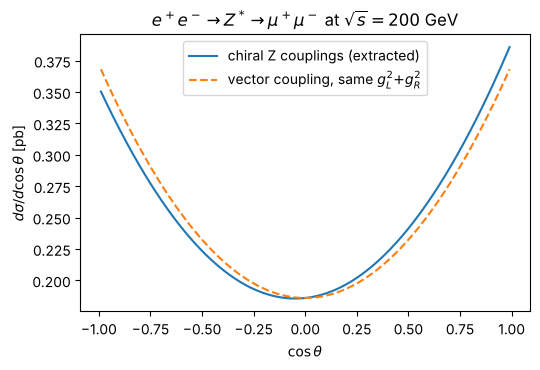

In [ ]:
# ---- peek: the tilt, against the symmetric vector-coupling curve. -------------
cosv = sp.Symbol("cosv", real=True)


def dsdcos_pb(m2, k, s_val=200.0**2):
    expr = differential_cross_section(m2, k, (electron, electron), variable="cos")
    f = sp.lambdify(cosv, expr.subs(k.t, k.t_of_cos(cosv)).subs(k.s, s_val) * GEV2_TO_PB, "numpy")
    return lambda x: np.real(f(x))


xs = np.linspace(-0.99, 0.99, 200)
plt.figure(figsize=(5.5, 3.8))
plt.plot(xs, dsdcos_pb(z_only.squared(), kz)(xs), label="chiral Z couplings (extracted)")
plt.plot(xs, dsdcos_pb(m2_vector, kz)(xs), "--", label=r"vector coupling, same $g_L^2{+}g_R^2$")
plt.xlabel(r"$\cos\theta$"); plt.ylabel(r"$d\sigma/d\cos\theta$ [pb]")
plt.title(r"$e^+e^-\to Z^*\to\mu^+\mu^-$ at $\sqrt{s}=200$ GeV")
plt.legend(); plt.tight_layout(); plt.show()

**Recognise.** Same area, different shape: the chiral curve leans forward. That lean is the
$\varepsilon\cdot\varepsilon$ term of §4, made visible — and it is small, $A_{FB}\approx0.04$,
because $A_e=A_\mu\approx0.2$ and it enters squared. (LEP quotes $\approx0.016$: its *effective*
$\sin^2\theta_\text{eff}=0.2315$ makes $A_\ell\approx0.15$; this notebook uses the on-shell
$s_W^2=1-M_W^2/M_Z^2\approx0.222$ of MadGraph's input scheme, and $A_\ell$ is very sensitive to
it.) Remember the number.

---
## 6. Two diagrams interfere — and the observable picks which couplings

Real $e^+e^-\to\mu^+\mu^-$ has **two** diagrams, γ and Z in the s channel, and nature adds
amplitudes, not probabilities:

$$\sum|\mathcal M_\gamma+\mathcal M_Z|^2=\sum|\mathcal M_\gamma|^2+\sum|\mathcal M_Z|^2
+2\,\mathrm{Re}\sum\mathcal M_\gamma\bar{\mathcal M}_Z .$$

The cross term has no single-diagram analogue. Each fermion line now carries $\Gamma$ from one
diagram and $\bar\Gamma$ from the other, $\mathrm{Tr}[\not k\,\Gamma_\gamma\not k'\,\bar\Gamma_Z]$, and
the propagators enter as $1/(D_\gamma\bar D_Z)$ — the Z's Breit–Wigner phase survives. Both
diagrams pair the four leptons into lines the same way, so this is still a product of two
traces.

> **Before running the next cells.** At $\sqrt s=200$ GeV we are far above the Z pole, so
> $s-M_Z^2>0$ and the Breit–Wigner phase is small. The γ couples to $Q$ alone, a pure *vector*
> coupling, so its interference with the Z can only pick out pieces of the Z couplings. Which
> pieces matter depends on the observable:
>
> - in the **total** σ it goes with the leptons' vector couplings, $g_V\propto g_L+g_R\propto
>   -\tfrac12+2s_W^2$ — nearly zero for $s_W^2\approx0.23$;
> - in $A_{FB}$ it goes with the axial couplings, $g_A\propto g_L-g_R=-\tfrac12$ — large.
>
> So: is the interference in σ big or small? And is $A_{FB}$ still the Z-only ≈ 0.04 of §5?

In [ ]:
# ---- MOVE 1 + 2: three processes -- photon only, Z only, both. ----------------
photon_only = ee_to((mu_p.particle, mu_p.antiparticle), [ph.A])
both = ee_to((mu_p.particle, mu_p.antiparticle), [ph.Z, ph.A])
trace("diagrams found for gamma + Z:", None)
print(both.diagrams)

sigma = {name: float(proc.cross_section().subs(proc.kinematics.s, 200.0**2)) * GEV2_TO_PB
         for name, proc in (("gamma", photon_only), ("Z", z_only), ("gamma+Z", both))}
interference = sigma["gamma+Z"] - sigma["gamma"] - sigma["Z"]
afb_both = float(both.forward_backward_asymmetry().subs(both.kinematics.s, 200.0**2))
for name, val in sigma.items():
    print(f"  sigma({name:7s}) = {val:.4f} pb")
print(f"  interference    = {interference:+.4f} pb     A_FB(gamma+Z) = {afb_both:.4f}")

diagrams found for gamma + Z:
[DiagramInfo(-s-channel A), DiagramInfo(-s-channel Z)]


  sigma(gamma  ) = 2.3223 pb
  sigma(Z      ) = 0.4959 pb
  sigma(gamma+Z) = 2.8443 pb
  interference    = +0.0261 pb     A_FB(gamma+Z) = 0.5653


In [ ]:
# ---- MOVE 4: both predictions, and the photon line against section 3. ---------
assert sorted((d.channel, str(d.mediator)) for d in both.diagrams) == [("s", "A"), ("s", "Z")]
assert close(sigma["gamma"], sigma_photon_pb, 1e-9)
ok("the calculator's photon-only sigma is section 3's hand-assembled 2.322 pb")
assert 0 < interference < 0.01 * sigma["gamma+Z"]
ok("the gamma-Z cross term is under 1% of sigma: it goes with g_V ~ -1/2 + 2 s_W^2 ~ 0")
assert afb_both > 10 * afb_z
ok(f"but A_FB jumps from {afb_z:.3f} (Z alone) to {afb_both:.3f}: there it goes with g_A")

✓ the calculator's photon-only sigma is section 3's hand-assembled 2.322 pb
✓ the gamma-Z cross term is under 1% of sigma: it goes with g_V ~ -1/2 + 2 s_W^2 ~ 0
✓ but A_FB jumps from 0.036 (Z alone) to 0.565: there it goes with g_A


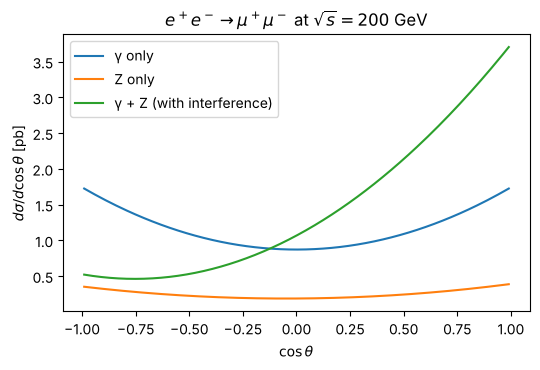

In [ ]:
# ---- peek: where the asymmetry comes from. -----------------------------------
plt.figure(figsize=(5.5, 3.8))
for label, proc in (("γ only", photon_only), ("Z only", z_only), ("γ + Z (with interference)", both)):
    plt.plot(xs, dsdcos_pb(proc.squared(), proc.kinematics)(xs), label=label)
plt.xlabel(r"$\cos\theta$"); plt.ylabel(r"$d\sigma/d\cos\theta$ [pb]")
plt.title(r"$e^+e^-\to\mu^+\mu^-$ at $\sqrt{s}=200$ GeV")
plt.legend(); plt.tight_layout(); plt.show()

**Recognise.** Neither diagram alone leans much: the photon is exactly symmetric and the Z
barely tilts. Their *sum* leans hard forward. At 200 GeV the forward–backward asymmetry is an
interference effect.

Now compare with a generator. MadGraph5_aMC@NLO [MG5aMC], run on feynlag's own exported UFO
and on its stock `sm` at this exact parameter point, reports $2.7878\pm0.0027$ pb
(`docs/benchmark.md`).

> **Before running the next cell.** That is 2% below the full-angle σ above — about 20 of
> MadGraph's standard deviations. Before suspecting the engine, ask what a generator's
> cross section *includes*.

In [ ]:
# ---- MOVE 4: the generator's number includes its default cuts. -----------------
c_eta = math.tanh(2.5)          # |eta| < 2.5  <=>  |cos theta| < tanh 2.5, massless leptons
sigma_cut = float(both.cross_section(cos_range=(-c_eta, c_eta)).subs(both.kinematics.s, 200.0**2)) * GEV2_TO_PB
print(f"sigma(gamma+Z), full angle   = {sigma['gamma+Z']:.4f} pb")
print(f"sigma(gamma+Z), |eta| < 2.5  = {sigma_cut:.4f} pb   (MadGraph: 2.7878 +- 0.0027 pb)")
assert abs(sigma["gamma+Z"] - 2.7878) > 10 * 0.0027
assert abs(sigma_cut - 2.7878) < 0.0027
ok("inside MadGraph's default lepton acceptance |eta| < 2.5, feynlag and MadGraph agree to 0.1 sigma")

sigma(gamma+Z), full angle   = 2.8443 pb
sigma(gamma+Z), |eta| < 2.5  = 2.7876 pb   (MadGraph: 2.7878 +- 0.0027 pb)
✓ inside MadGraph's default lepton acceptance |eta| < 2.5, feynlag and MadGraph agree to 0.1 sigma


**Recognise.** MadGraph's run card cuts charged leptons at $|\eta|<2.5$ by default; for massless
leptons $\eta=-\ln\tan(\theta/2)$, so the cut is $|\cos\theta|<\tanh2.5$. With the same
acceptance the two agree. Always find out what a benchmark number includes before comparing
to it.

---
## 7. Exchanged pairings: one trace, one minus sign

For $e^+e^-\to e^+e^-$ — **Bhabha** scattering [Bhabha36] — the outgoing electron can also be
the *incoming* electron continuing, after exchanging a photon with the positron: a **t-channel**
diagram. Now the two diagrams pair the four external spinors into lines **differently**. The s
channel pairs (in, in) and (out, out); the t channel pairs (in e⁻, out e⁻) and (in e⁺, out e⁺).

Two things follow, and both are new.

1. **A relative sign.** Wick's theorem contracts four fermion operators, and the two pairings
   differ by an odd permutation of them. The calculator reads each diagram's sign off as the
   parity of the permutation (bar slot, field slot, bar slot, field slot) of the external
   labels. (Which slot is which is the external-line rule: an incoming particle or an outgoing
   antiparticle is a *field* slot, $u$ or $v$; an outgoing particle or an incoming
   antiparticle is a *bar* slot, $\bar u$ or $\bar v$.)
2. **One trace, not two.** In $\mathcal M_s\bar{\mathcal M}_t$ the spinor lines no longer close
   separately. Following $u\bar u$ and $v\bar v$ around, the four spin sums chain into a
   *single* trace through all four legs, with every Lorentz index contracted inside it. Its
   $\gamma_5$ part is then an $\varepsilon$ of external momenta only, which §4 proved zero.

The QED result is [PS95, Problem 5.2]

$$\sum|\mathcal M|^2=8e^4\left[\frac{s^2+u^2}{t^2}+\frac{2u^2}{st}+\frac{t^2+u^2}{s^2}\right].$$

> **Before running the next cell.** Which of the three terms is the s–t interference — and
> which of them makes the forward ($t\to0$) cross section blow up?

In [ ]:
# ---- MOVE 1 + 4: Bhabha from the model, against the closed form. ----------------
bhabha = ee_to((e_p.particle, e_p.antiparticle), [ph.A], particles=(e_p,), masses={ph.A: 0})
print(bhabha.diagrams)
signs = {d.channel: d.sign for d in bhabha.diagrams}
assert set(signs) == {"s", "t"} and signs["s"] == -signs["t"]
ok("two diagrams, s and t, with opposite fermion-permutation signs")

kb = bhabha.kinematics
closed_bhabha = 8 * e_mg**4 * ((kb.s**2 + kb.u**2) / kb.t**2 + 2 * kb.u**2 / (kb.s * kb.t)
                               + (kb.t**2 + kb.u**2) / kb.s**2)
for point in ({kb.s: 4e4, kb.t: -1.2e4}, {kb.s: 900.0, kb.t: -50.0}):
    assert close(complex(bhabha.squared().subs(point)).real, float(closed_bhabha.subs(point)), 1e-10)
ok("Sigma|M|^2 = 8e^4 [(s^2+u^2)/t^2 + 2u^2/(st) + (t^2+u^2)/s^2]   [PS95 Problem 5.2]")

[DiagramInfo(-s-channel A), DiagramInfo(+t-channel A)]
✓ two diagrams, s and t, with opposite fermion-permutation signs


✓ Sigma|M|^2 = 8e^4 [(s^2+u^2)/t^2 + 2u^2/(st) + (t^2+u^2)/s^2]   [PS95 Problem 5.2]


Is the sign physics or convention? Build the same two diagrams **by hand** with the `Leg` /
`SpinorChain` / `ChainVertex` / `BosonPropagator` / `Diagram` objects the calculator itself
uses, give them the *same* sign, and see what changes.

> **Before running the next cell.** If the relative sign were $+1$, which term of the closed form
> would flip, and by how much would $\sum|\mathcal M|^2$ change?

In [ ]:
# ---- MOVE 1 + 2 + 4: the two Bhabha diagrams by hand, both signs. ---------------
def line(bar_leg, field_leg, coupling, tag):
    mu_a, mu_b = _chain_indices(tag)
    return SpinorChain(out=bar_leg, inn=field_leg,
                       vertices=(ChainVertex("V", coupling, coupling),),
                       indices=(mu_a,), bar_indices=(mu_b,))


ks = TwoToTwoKinematics(0, 0, 0, 0)
e1, p2 = Leg(ks.k1, 0), Leg(ks.k2, 0, anti=True)      # incoming e-, incoming e+
e3, p4 = Leg(ks.k3, 0), Leg(ks.k4, 0, anti=True)      # outgoing e-, outgoing e+
vertex = -sp.I * e                                     # the photon vertex, symbolic e


def bhabha_by_hand(t_sign):
    s_diag = Diagram(chains=(line(p2, e1, vertex, "hs1"), line(e3, p4, vertex, "hs2")),
                     propagators=(BosonPropagator(1, ks.s, 0),), coefficient=-1)
    t_diag = Diagram(chains=(line(e3, e1, vertex, "ht1"), line(p2, p4, vertex, "ht2")),
                     propagators=(BosonPropagator(1, ks.t, 0),), coefficient=t_sign)
    return Amplitude((s_diag, t_diag)).squared(ks)


right, wrong = bhabha_by_hand(+1), bhabha_by_hand(-1)
S_, T_, U_ = ks.s, ks.t, ks.u
assert sp.simplify(right - 8 * e**4 * ((S_**2 + U_**2) / T_**2 + 2 * U_**2 / (S_ * T_)
                                      + (T_**2 + U_**2) / S_**2)) == 0
assert sp.simplify(right - wrong - 32 * e**4 * U_**2 / (S_ * T_)) == 0
ok("opposite signs reproduce the closed form; equal signs flip the 2u^2/(st) term -- "
   "an error of exactly 32 e^4 u^2/(st)")

✓ opposite signs reproduce the closed form; equal signs flip the 2u^2/(st) term -- an error of exactly 32 e^4 u^2/(st)


**Recognise.** The $2u^2/(st)$ term is the s–t interference, and the relative minus sign is what
gives it its sign: it is physics, fixed by Fermi statistics, not a convention a calculator may
choose. The $1/t^2$ term is the forward photon pole — the full-angle Bhabha cross section is
infinite, which is why Bhabha scattering at small angles is how colliders measure their
luminosity, and why any Bhabha σ needs an angular cut.

---
## 8. Capstone: Møller scattering by hand

$e^-e^-\to e^-e^-$ — **Møller** scattering [Møller32] — has no s channel at all: two electrons
cannot annihilate. Build it without the calculator, using only the slot rule and Wick's sign
rule from §7, then hold `ScatteringCalculator` to account.

> **Before running the next cells.** Work these out on paper first.
>
> 1. All four legs are electrons. Which momenta sit in field slots ($u$) and which in bar slots
>    ($\bar u$)?
> 2. There are two ways to pair bar slots with field slots. Which channel ($t$ or $u$) is each?
> 3. Write each pairing as (bar, field, bar, field) in terms of the labels $1..4$, and compute
>    its permutation parity. Is the relative sign $-1$?
> 4. Two identical electrons in the final state: what extra factor must the cross section carry?

In [ ]:
# ---- MOVE 1: slots, pairings and signs, worked by hand. ------------------------
# incoming particles k1, k2 -> field slots (u);  outgoing particles k3, k4 -> bar slots (u-bar)
pairing_t = [2, 0, 3, 1]          # (bar k3, field k1), (bar k4, field k2): q = k1 - k3, t channel
pairing_u = [2, 1, 3, 0]          # (bar k3, field k2), (bar k4, field k1): q = k1 - k4, u channel
sign_t = Permutation(pairing_t).signature()
sign_u = Permutation(pairing_u).signature()
print(f"sign(t) = {sign_t:+d},  sign(u) = {sign_u:+d}")
assert sign_t == -sign_u
ok("the two Moller pairings differ by an odd permutation: relative sign -1")

km = TwoToTwoKinematics(0, 0, 0, 0)
a1, a2, a3, a4 = (Leg(k, 0) for k in (km.k1, km.k2, km.k3, km.k4))
t_hand = Diagram(chains=(line(a3, a1, vertex, "mt1"), line(a4, a2, vertex, "mt2")),
                 propagators=(BosonPropagator(1, km.t, 0),), coefficient=sign_t)
u_hand = Diagram(chains=(line(a3, a2, vertex, "mu1"), line(a4, a1, vertex, "mu2")),
                 propagators=(BosonPropagator(1, km.u, 0),), coefficient=sign_u)
moller_hand = Amplitude((t_hand, u_hand)).squared(km)

sign(t) = -1,  sign(u) = +1
✓ the two Moller pairings differ by an odd permutation: relative sign -1


In [ ]:
# ---- MOVE 2 + 4: the crossed Bhabha form, and the calculator's own build. -------
S_, T_, U_ = km.s, km.t, km.u
crossed = 8 * e**4 * ((S_**2 + U_**2) / T_**2 + 2 * S_**2 / (T_ * U_) + (S_**2 + T_**2) / U_**2)
assert sp.simplify(moller_hand - crossed) == 0
ok("hand-built Moller = Bhabha's closed form with s <-> u (crossing)")

e_calc = ScatteringCalculator(model, [e_p], masses={ph.A: 0}, boson_fields=[ph.A],
                              conjugate_map=ph.cmap)
moller = e_calc.process((e_p.particle, e_p.particle), (e_p.particle, e_p.particle),
                        numeric=True, extra=values)
assert sorted(d.channel for d in moller.diagrams) == ["t", "u"]
assert moller.symmetry_factor == sp.Rational(1, 2)
for point in ({km.s: 100.0, km.t: -30.0}, {km.s: 2500.0, km.t: -900.0}):
    calc_val = complex(moller.squared().subs(point)).real
    hand_val = float(moller_hand.subs(e, e_mg).subs(point))
    assert close(calc_val, hand_val, 1e-10)
ok("the calculator finds the same two diagrams, the same |M|^2, and applies the identical-particle 1/2")

✓ hand-built Moller = Bhabha's closed form with s <-> u (crossing)


✓ the calculator finds the same two diagrams, the same |M|^2, and applies the identical-particle 1/2


In [ ]:
# ---- MOVE 4: the identical-particle factor, in a cross section. -----------------
s_val, c_max = 200.0**2, 0.9
f_hand = sp.lambdify(cosv, moller_hand.subs(e, e_mg).subs(km.t, km.t_of_cos(cosv)).subs(km.s, s_val), "numpy")
nodes, weights = np.polynomial.legendre.leggauss(200)
integral = c_max * sum(w * f_hand(c_max * x) for x, w in zip(nodes, weights))
sigma_hand = 0.5 * 0.25 * integral / (32 * math.pi * s_val)      # 1/2 identical, 1/4 spins
sigma_calc = moller.numeric_cross_section(s_val, cos_range=(-c_max, c_max))
print(f"sigma(e-e- -> e-e-, |cos| < 0.9) = {sigma_calc * GEV2_TO_PB:.2f} pb")
assert close(sigma_calc, sigma_hand, 1e-8)
ok("hand quadrature (1/2 x 1/4 x Sigma|M|^2 / 32 pi s) == the calculator's numeric_cross_section")

sigma(e-e- -> e-e-, |cos| < 0.9) = 135.14 pb
✓ hand quadrature (1/2 x 1/4 x Sigma|M|^2 / 32 pi s) == the calculator's numeric_cross_section


**Recognise.** Nothing in the calculator is special to Bhabha: the slot rule, the permutation
sign and the single-trace route are general, so Møller — and $\nu_ee^-\to\nu_ee^-$, where a
t-channel Z interferes with a u-channel W (`tests/test_interference.py` pins that sign through
the Fierz identity's "$g_L\to g_L+1$") — comes out of the same code. The ½ is not a dynamical
effect: integrating over the full angle counts every two-electron final state twice.

---
## 9. Recap

**The mechanics.**

1. A 2→2 event has two invariants. feynlag uses $(s,t)$ and derives $u$, so momentum
   conservation is never an extra check.
2. $d\sigma/d\cos\theta=\overline{|\mathcal M|^2}/(32\pi s)$ for massless particles; the initial
   spin average is declared data (`ExternalState`), applied once.
3. A chiral current's trace carries a $\gamma_5$ piece. A single $\varepsilon$ of external
   momenta always vanishes (the four-momentum Gram determinant is zero); the product of two
   does not — that is the forward–backward asymmetry.
4. Amplitudes add. Diagrams that pair the external fermions the same way interfere through a
   product of two traces; diagrams that pair them differently interfere through **one** trace,
   with a relative minus sign from Fermi statistics.
5. Which couplings an interference term sees depends on the observable: $g_V$ in $\sigma$,
   $g_A$ in $A_{FB}$.
6. A generator's cross section includes its default cuts.

**The tools, in the order you should reach for them.**

| question | tool |
|---|---|
| kinematics, $u$, $t$-range, flux | `TwoToTwoKinematics` (`.u`, `.t_bounds()`, `.t_of_cos()`, `.flux_factor()`) |
| $d\sigma$, $\sigma$ from a $\sum\lvert\mathcal M\rvert^2$ | `differential_cross_section`, `cross_section(..., cos_range=)` |
| one s-channel vector or scalar, couplings in hand | `ffv_s_channel_squared`, `ffs_s_channel_squared` |
| build an amplitude yourself | `Leg`, `ChainVertex`, `SpinorChain`, `BosonPropagator`, `Diagram`, `Amplitude.squared` |
| the $\gamma_5$ constants and the independence test | `gamma5_trace_coefficient`, `epsilon_product_sign`, `gram_determinant` |
| every diagram of a process, from a model | `ScatteringCalculator(...).process(incoming, outgoing, numeric=True)` |
| a number fast | `ScatteringProcess.numeric_cross_section(s, cos_range)` |
| the asymmetry | `forward_backward_asymmetry` / `ScatteringProcess.forward_backward_asymmetry()` |

**Where this leaves the roadmap** (`docs/manual/scattering_roadmap.md`).

| tier | status | what it adds |
|---|---|---|
| 1 | ✅ | kinematics, one diagram — §1–§3 |
| 2 | ✅ | the $\varepsilon$ ($\gamma_5$) algebra — §4–§5 |
| 3 | ✅ | interference and s/t/u topologies — §6–§8 |
| 4 | — | derivative couplings: $e^+e^-\to W^+W^-$ and its gauge cancellation |
| 5 | — | coloured / hadronic 2→2 at parton level |

---
## 10. References

- **[PS95]** M. E. Peskin and D. V. Schroeder, *An Introduction to Quantum Field Theory*,
  Addison-Wesley (1995), ISBN 0-201-50397-2 — §5.1 ($e^+e^-\to\mu^+\mu^-$) and Problem 5.2
  (Bhabha scattering).
- **[LEPEWWG06]** ALEPH, DELPHI, L3, OPAL, SLD Collaborations, LEP Electroweak Working Group,
  SLD Electroweak and Heavy Flavour Groups, *Precision Electroweak Measurements on the Z
  Resonance*, Phys. Rept. **427** (2006) 257,
  [arXiv:hep-ex/0509008](https://arxiv.org/abs/hep-ex/0509008),
  doi:[10.1016/j.physrep.2005.12.006](https://doi.org/10.1016/j.physrep.2005.12.006) —
  Eqs. (1.55), (1.56), (1.66).
- **[Bhabha36]** H. J. Bhabha, *The scattering of positrons by electrons with exchange on
  Dirac's theory of the positron*, Proc. R. Soc. Lond. A **154** (1936) 195–206,
  doi:[10.1098/rspa.1936.0046](https://doi.org/10.1098/rspa.1936.0046).
- **[Møller32]** C. Møller, *Zur Theorie des Durchgangs schneller Elektronen durch Materie*,
  Ann. Phys. **406** (1932) 531–585,
  doi:[10.1002/andp.19324060506](https://doi.org/10.1002/andp.19324060506).
- **[MG5aMC]** J. Alwall, R. Frederix, S. Frixione, V. Hirschi, F. Maltoni, O. Mattelaer,
  H.-S. Shao, T. Stelzer, P. Torrielli and M. Zaro, *The automated computation of tree-level
  and next-to-leading order differential cross sections, and their matching to parton shower
  simulations*, JHEP **07** (2014) 079, [arXiv:1405.0301](https://arxiv.org/abs/1405.0301),
  doi:[10.1007/JHEP07(2014)079](https://doi.org/10.1007/JHEP07(2014)079).
- **[PDG]** Particle Data Group, *Review of Particle Physics* — "Kinematics" review and the
  physical-constants table ($\hbar c$ conversion), current edition at
  [pdg.lbl.gov](https://pdg.lbl.gov/).